# Plot histograms of entangled input parallelism score
Generate histogram of parallelism scores (PS) of entangled whisker contacts fed as input to prediction models, or $\text{PS}(h_{\text{entangler}}(\mathbf{X}_{i}))$ across all prediction model instances $i$.

##### Import statements:

In [1]:
import os
import pathlib
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib import colormaps
from analysis_metadata.analysis_metadata import Metadata, increment_dir_name, write_metadata

##### Define inputs, parameters:

In [3]:
# Input file:
input_path = os.path.join('/', 'mnt', 'smb', 'locker', 'issa-locker', 'users', 'Dan', 'code', 'ws', 'results', 'run845', 'tngl_pred.pickle')
input_dir = os.path.split(input_path)[0]

# Output parameters:
save_output = True
base_dir_name = 'delta_ps_v_ps_entangler'

##### Load previously-saved results:

In [4]:
tngl_evo_pred_results = pickle.load(open(input_path, 'rb'))
geo_df = tngl_evo_pred_results['geo_df'] 
loss_df = tngl_evo_pred_results['ae_df']

##### Compute entangler model parallelism score **on** data $\mathbf{X}_0$ used to train it, i.e. $\text{PS}(h_{\text{entangler}}(\mathbf{X}_0))$:

In [29]:
# Select results for final epoch of entangler model hidden layer:
geo_df_tngl = geo_df[geo_df.mdl_type=='autoencoder']
tngl_final_epoch = geo_df_tngl.epoch.max()
geo_df_tngl_hidden = geo_df_tngl[
    np.array(geo_df_tngl.layer=='hidden') & 
    np.array(geo_df_tngl.epoch==tngl_final_epoch)
]

X0_mu = geo_df_tngl_hidden[['dichotomy', 'parallelism']]\
    .groupby('dichotomy').mean()\
    .mean().reset_index(name='parallelism')
X0_mu = X0_mu.iloc[0].parallelism

##### Computeparallelism score for  prediction model inputs, i.e. $\text{PS}(h_{\text{entangler}}(\mathbf{X}_i))$: 

In [50]:
geo_df_pred_inpt = geo_df[np.array(geo_df.mdl_type=='prediction') & 
    np.array(geo_df.layer=='inpt') &
    np.array(geo_df.epoch==0)
    ]

# Take mean PS for each prediction model:
geo_df_pred_mu = geo_df_pred_inpt[['pred_mdl_id', 'dichotomy_idx', 'parallelism']]\
    .groupby(['pred_mdl_id', 'dichotomy_idx']).mean()\
    .groupby('pred_mdl_id').mean().reset_index()

##### Plot histogram of $\text{PS}(h_{\text{entangler}}(\mathbf{X}_i))$ with reference line for $\text{PS}(h_{\text{entangler}}(\mathbf{X}_0))$:

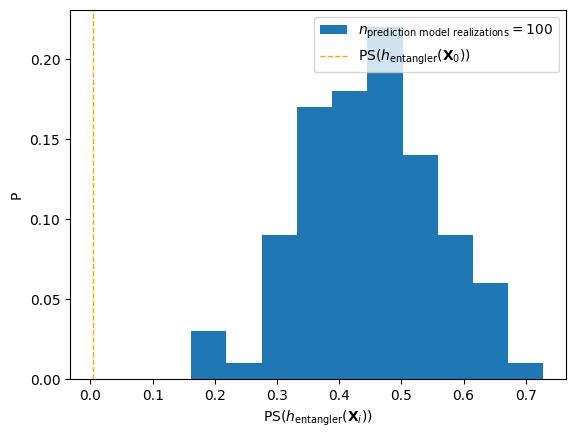

In [51]:
hist_fig, hist_ax = plt.subplots()

# Plot histogram:
hist_label = r'$n_{{\text{{prediction model realizations}}}} = {}$'.format(geo_df_pred_mu.shape[0])
plt.hist(geo_df_pred_mu.parallelism, weights=(1/geo_df_pred_mu.shape[0])*np.ones(geo_df_pred_mu.shape[0]), label=hist_label)

# Add reference line:
refline_label = r'$\text{PS}(h_{\text{entangler}}(\mathbf{X}_0))$'
plt.axvline(X0_mu, color='orange', linewidth=1, linestyle='--', label=refline_label)

# Add axis labels:
xlabel_str = r'$\text{PS}(h_{\text{entangler}}(\mathbf{X}_{i}))$'
plt.ylabel('P')
plt.xlabel(xlabel_str)

plt.legend()

##### Save output:

In [41]:
if save_output:

    # Create output directory:
    input_dir = os.path.split(input_path)[0]
    base_dir_name = 'ps_pred_hist_w_ps_tngl'
    curr_output_directory = increment_dir_name(input_dir, base_dir_name)
    if not os.path.exists(curr_output_directory):
        pathlib.Path(curr_output_directory).mkdir(parents=True,exist_ok=True)

    # Save figures:
    plt.figure(hist_fig)
    file_basename = base_dir_name
    ps_png_path = os.path.join(curr_output_directory, file_basename+'.png')
    plt.savefig(ps_png_path)
    ps_svg_path =  os.path.join(curr_output_directory, file_basename+'.svg')
    plt.savefig(ps_svg_path)
    
    # Define metadata:
    M = Metadata()
    M.add_input(input_path)
    M.add_output(ps_png_path)
    M.add_output(ps_svg_path)
    metadata_path = os.path.join(curr_output_directory, file_basename + '.json')
    write_metadata(M, metadata_path)

Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run845/tngl_pred.pickle...
Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run845/ps_pred_hist_w_ps_tngl002/ps_pred_hist_w_ps_tngl.png...
Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run845/ps_pred_hist_w_ps_tngl002/ps_pred_hist_w_ps_tngl.svg...
